In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
!pip install catboost xgboost
from catboost import CatBoostClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# load data
df = pd.read_csv("diabetic_data.csv")
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## data cleaning and outliers

In [3]:
# drop duplicates by encounter_id
df.drop_duplicates(subset='encounter_id', inplace=True)
# replace '?' with NaN value
df.replace('?', pd.NA, inplace=True)

In [4]:
missing_percent = df.isna().mean() * 100
print(missing_percent)
# drop columns with high missingness
df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum               94.746772
A1Cresult                   83.277322
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [5]:
# drop any medication columns that contain unique value (all No column)
drug_cols = df.columns[24:44]  #from column 24 to 44
to_drop = [col for col in drug_cols if df[col].nunique(dropna=False) <= 1]
df.drop(columns=to_drop, inplace=True)


In [6]:
print(df['gender'].value_counts())
# remove Unknown/Invalid from gender
df = df[df['gender'] != 'Unknown/Invalid']

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [7]:
# drop identifier columns that carry no predictive value
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

In [8]:
# clean the 'age' column by removing brackets
df['age'] = df['age'].str.replace(r'[\[\]\(\)]', '', regex=True)
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,0-10,6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,10-20,1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,20-30,1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,30-40,1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,40-50,1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
# Convert 'readmitted' into binary (category encoding)
df['readmitted_binary'] = df['readmitted'].replace({'>30': 0, '<30': 1, 'NO': 0})
# drop the old one
df.drop(columns=['readmitted'], inplace=True, errors='ignore')
#df.head()

C:\Users\JunhuiHuTEST\AppData\Local\Temp\ipykernel_23844\1876382924.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted_binary'] = df['readmitted'].replace({'>30': 0, '<30': 1, 'NO': 0})


In [10]:
# numerical feature outlier check
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'number_inpatient',
                'number_outpatient', 'number_emergency']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col} outliers: {n_outliers}")

time_in_hospital outliers: 2252
num_lab_procedures outliers: 143
number_inpatient outliers: 7049
number_outpatient outliers: 16739
number_emergency outliers: 11383


In [11]:
# Diagnosis Category base on IDC-9
def map_diagnosis_category(code):
    try:
        code_str = str(code)
        if code_str.startswith('V') or code_str.startswith('E'):
            return 'External/Supplemental'
        code_num = float(code)
        if 390 <= code_num <= 459 or code_num == 785:
            return 'Circulatory'
        elif 460 <= code_num <= 519 or code_num == 786:
            return 'Respiratory'
        elif 520 <= code_num <= 579 or code_num == 787:
            return 'Digestive'
        elif 250 <= code_num < 251:
            return 'Diabetes'
        elif 800 <= code_num <= 999:
            return 'Injury'
        elif 710 <= code_num <= 739:
            return 'Musculoskeletal'
        elif 580 <= code_num <= 629 or code_num == 788:
            return 'Genitourinary'
        elif 140 <= code_num <= 239:
            return 'Neoplasms'
        elif 290 <= code_num <= 319:
            return 'Mental/Behavioral'
        elif 240 <= code_num <= 279 and not (250 <= code_num < 251):
            return 'Endocrine (non-diabetes)'
        elif 680 <= code_num <= 709 or code_num == 782:
            return 'Skin/Subcutaneous'
        elif 1 <= code_num <= 139:
            return 'Infectious'
        elif 240 <= code_num <= 279:
            return 'Endocrine (non-diabetes)'
        elif 280 <= code_num <= 289:
            return 'Blood'
        elif 290 <= code_num <= 319:
            return 'Mental/Behavioral'
        elif 360 <= code_num <= 389:
            return 'Sense Organs'
        elif 740 <= code_num <= 759:
            return 'Congenital Anomalies'
        elif 630 <= code_num <= 679:
            return 'Pregnancy/Childbirth'
        else:
            return 'Other'
    except:
        return 'Other'

# apply mapping to 'diag_1', 'diag_2', 'diag_3'
for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    new_col = diag_col + '_cat'
    df[new_col] = df[diag_col].apply(map_diagnosis_category)

# drop the original numeric/string ICD-9 columns
df.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary,diag_1_cat,diag_2_cat,diag_3_cat
0,Caucasian,Female,0-10,6,25,1,1,41,0,1,...,No,No,No,No,No,No,0,Diabetes,Other,Other
1,Caucasian,Female,10-20,1,1,7,3,59,0,18,...,No,No,No,No,Ch,Yes,0,Endocrine (non-diabetes),Diabetes,Endocrine (non-diabetes)
2,AfricanAmerican,Female,20-30,1,1,7,2,11,5,13,...,No,No,No,No,No,Yes,0,Pregnancy/Childbirth,Diabetes,External/Supplemental
3,Caucasian,Male,30-40,1,1,7,2,44,1,16,...,No,No,No,No,Ch,Yes,0,Infectious,Diabetes,Circulatory
4,Caucasian,Male,40-50,1,1,7,1,51,0,8,...,No,No,No,No,Ch,Yes,0,Neoplasms,Neoplasms,Diabetes


In [12]:
# feature engineering (fixed insulin column duplication)

# Flags for multi-visit, inpatient, emergency
df['multi_visit']    = ((df['number_inpatient'] +
                         df['number_emergency'] +
                         df['number_outpatient']) > 1).astype(int)
df['had_inpatient']  = (df['number_inpatient'] > 0).astype(int)
df['had_emergency']  = (df['number_emergency'] > 0).astype(int)

# Flag high medication count (above the mean)
avg_med_count = df['num_medications'].mean()
df['high_med_count'] = (df['num_medications'] > avg_med_count).astype(int)

# DROP any existing insulin columns to avoid duplicates
for insulin_col in ['insulin_Steady', 'insulin_Up', 'insulin_Down']:
    if insulin_col in df.columns:
        df.drop(columns=[insulin_col], inplace=True)

# Recreate “fresh” insulin columns (all zeros)
df['insulin_Steady'] = 0
df['insulin_Up']     = 0
df['insulin_Down']   = 0

# Create combined insulin_user flag
df['insulin_user'] = ((df['insulin_Steady'] == 1) |
                      (df['insulin_Up'] == 1)     |
                      (df['insulin_Down'] == 1)).astype(int)

# Changed medication flag
if 'change_Yes' in df.columns:
    df['changed_med'] = df['change_Yes'].astype(int)
else:
    df['changed_med'] = 0

# Combined metformin + glipizide flag
if 'metformin_Steady' in df.columns and 'glipizide_Steady' in df.columns:
    df['combo_met_glip'] = ((df['metformin_Steady'] == 1) &
                            (df['glipizide_Steady'] == 1)).astype(int)
else:
    df['combo_met_glip'] = 0


In [13]:
# One-Hot Encoding except diag_1-3

# identify all object type columns
object_cols = df.select_dtypes(include="object").columns.tolist()

# remove diag_1_cat, diag_2_cat, diag_3_cat from that list so we can encode them separately
for col in ["diag_1_cat", "diag_2_cat", "diag_3_cat","insulin_Steady","insulin_Up","insulin_Down"]:
    if col in object_cols:
        object_cols.remove(col)

# One‐hot encode all other object_cols with drop_first=True
if object_cols:
    df = pd.get_dummies(df, columns=object_cols, drop_first=True)

In [14]:
# one‐hot encode each diag_xxx_cat column
diag_cat_cols = [c for c in ["diag_1_cat", "diag_2_cat", "diag_3_cat"] if c in df.columns]
if diag_cat_cols:
    df = pd.get_dummies(
        df, columns=diag_cat_cols, prefix=["diag1", "diag2", "diag3"], drop_first=True
    )

In [15]:
df.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag3_Infectious,diag3_Injury,diag3_Mental/Behavioral,diag3_Musculoskeletal,diag3_Neoplasms,diag3_Other,diag3_Pregnancy/Childbirth,diag3_Respiratory,diag3_Sense Organs,diag3_Skin/Subcutaneous
0,6,25,1,1,41,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False
1,1,1,7,3,59,0,18,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,1,1,7,2,11,5,13,2,0,1,...,False,False,False,False,False,False,False,False,False,False
3,1,1,7,2,44,1,16,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,1,1,7,1,51,0,8,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [16]:
# prepare final feature matrix X and target y

X = df.drop(columns=['readmitted_binary'], errors='ignore')
y = df['readmitted_binary']

duplicate_cols = X.columns[X.columns.duplicated()]
print("Duplicate columns in X before removal:", duplicate_cols.tolist())
X = X.loc[:, ~X.columns.duplicated()]
print("Remaining columns count after de-duplication:", len(X.columns))

Duplicate columns in X before removal: ['insulin_Steady', 'insulin_Up']
Remaining columns count after de-duplication: 138


In [17]:
# three-way split: 64% train, 16% validation, 20% test (stratified)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.20,  # 0.2 *0.8 =0.16
    random_state=42,
    stratify=y_temp
)

print("Shape Check:")
print(f"  X_train: {X_train.shape},   Positives: {y_train.sum()}")
print(f"  X_val:   {X_val.shape},   Positives: {y_val.sum()}")
print(f"  X_test:  {X_test.shape},   Positives: {y_test.sum()}")

Shape Check:
  X_train: (65128, 138),   Positives: 7269
  X_val:   (16282, 138),   Positives: 1817
  X_test:  (20353, 138),   Positives: 2271


In [18]:
X_train.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [19]:
# utility: function to find roc-optimal threshold by using youden's j
def find_best_threshold(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx]

## Model build


In [20]:
# storage for best estimators and thresholds
best_models = {}
best_thresholds = {}

In [21]:
# ---- CATBOOST ----
print("\n=== CATBOOST TUNING ===")
cb_base = CatBoostClassifier(verbose=False, random_state=42)
param_grid_cb = {
    'iterations':    [200, 300],
    'learning_rate': [0.03, 0.1],
    'depth':         [4, 6]
}

grid_cb = GridSearchCV(
    estimator=cb_base,
    param_grid=param_grid_cb,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)
grid_cb.fit(X_train, y_train)
print("CatBoost Best Params:", grid_cb.best_params_)
cb_best = grid_cb.best_estimator_
best_models['CatBoost'] = cb_best


=== CATBOOST TUNING ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
CatBoost Best Params: {'depth': 6, 'iterations': 300, 'learning_rate': 0.1}


In [22]:
# Validation performance at threshold=0.5
y_val_proba_cb = cb_best.predict_proba(X_val)[:, 1]
y_val_pred_cb_default = (y_val_proba_cb >= 0.5).astype(int)
print("\nCatBoost Validation (threshold=0.5):")
print(classification_report(y_val, y_val_pred_cb_default, zero_division=0))

# Find ROC-optimal threshold on validation
thr_cb = find_best_threshold(y_val, y_val_proba_cb)
best_thresholds['CatBoost'] = thr_cb
print(f"CatBoost ROC‐optimal threshold: {thr_cb:.3f}")

y_val_pred_cb_opt = (y_val_proba_cb >= thr_cb).astype(int)
print("\nCatBoost Validation (ROC-optimal threshold):")
print(classification_report(y_val, y_val_pred_cb_opt, zero_division=0))


CatBoost Validation (threshold=0.5):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14465
           1       0.52      0.02      0.03      1817

    accuracy                           0.89     16282
   macro avg       0.70      0.51      0.49     16282
weighted avg       0.85      0.89      0.84     16282

CatBoost ROC‐optimal threshold: 0.108

CatBoost Validation (ROC-optimal threshold):
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     14465
           1       0.18      0.63      0.28      1817

    accuracy                           0.64     16282
   macro avg       0.56      0.63      0.52     16282
weighted avg       0.85      0.64      0.70     16282



In [23]:
# ---- DECISION TREE ----
print("\n=== DECISION TREE TUNING ===")
dt_base = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth':        [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 5]
}

grid_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)
print("Decision Tree Best Params:", grid_dt.best_params_)
dt_best = grid_dt.best_estimator_
best_models['DecisionTree'] = dt_best


=== DECISION TREE TUNING ===
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Decision Tree Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [24]:
# Validation performance at threshold=0.5
y_val_proba_dt = dt_best.predict_proba(X_val)[:, 1]
y_val_pred_dt_default = (y_val_proba_dt >= 0.5).astype(int)
print("\nDecision Tree Validation (threshold=0.5):")
print(classification_report(y_val, y_val_pred_dt_default, zero_division=0))

# Find ROC-optimal threshold on validation
thr_dt = find_best_threshold(y_val, y_val_proba_dt)
best_thresholds['DecisionTree'] = thr_dt
print(f"Decision Tree ROC‐optimal threshold: {thr_dt:.3f}")

y_val_pred_dt_opt = (y_val_proba_dt >= thr_dt).astype(int)
print("\nDecision Tree Validation (ROC-optimal threshold):")
print(classification_report(y_val, y_val_pred_dt_opt, zero_division=0))


Decision Tree Validation (threshold=0.5):
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     14465
           1       0.17      0.19      0.18      1817

    accuracy                           0.80     16282
   macro avg       0.53      0.54      0.53     16282
weighted avg       0.82      0.80      0.81     16282

Decision Tree ROC‐optimal threshold: 1.000

Decision Tree Validation (ROC-optimal threshold):
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     14465
           1       0.17      0.19      0.18      1817

    accuracy                           0.80     16282
   macro avg       0.53      0.54      0.53     16282
weighted avg       0.82      0.80      0.81     16282



In [25]:
# ---- RANDOM FOREST ----
print("\n=== RANDOM FOREST TUNING ===")
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators':       [100, 200],
    'max_depth':          [None, 10, 20],
    'min_samples_split':  [2, 5],
    'min_samples_leaf':   [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)
print("Random Forest Best Params:", grid_rf.best_params_)
rf_best = grid_rf.best_estimator_
best_models['RandomForest'] = rf_best


=== RANDOM FOREST TUNING ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Random Forest Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [26]:
# Validation performance @ threshold=0.5
y_val_proba_rf = rf_best.predict_proba(X_val)[:, 1]
y_val_pred_rf_default = (y_val_proba_rf >= 0.5).astype(int)
print("\nRandom Forest Validation (threshold=0.5):")
print(classification_report(y_val, y_val_pred_rf_default, zero_division=0))

# Find ROC-optimal threshold on validation
thr_rf = find_best_threshold(y_val, y_val_proba_rf)
best_thresholds['RandomForest'] = thr_rf
print(f"Random Forest ROC‐optimal threshold: {thr_rf:.3f}")

y_val_pred_rf_opt = (y_val_proba_rf >= thr_rf).astype(int)
print("\nRandom Forest Validation (ROC-optimal threshold):")
print(classification_report(y_val, y_val_pred_rf_opt, zero_division=0))


Random Forest Validation (threshold=0.5):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14465
           1       0.57      0.01      0.01      1817

    accuracy                           0.89     16282
   macro avg       0.73      0.50      0.48     16282
weighted avg       0.85      0.89      0.84     16282

Random Forest ROC‐optimal threshold: 0.130

Random Forest Validation (ROC-optimal threshold):
              precision    recall  f1-score   support

           0       0.92      0.64      0.76     14465
           1       0.17      0.56      0.26      1817

    accuracy                           0.64     16282
   macro avg       0.54      0.60      0.51     16282
weighted avg       0.84      0.64      0.70     16282



In [27]:
# ---- XGBOOST ----
print("\n=== XGBOOST TUNING ===")
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
param_grid_xgb = {
    'n_estimators':     [100, 200],
    'learning_rate':    [0.05, 0.1],
    'max_depth':        [3, 5, 7],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)
print("XGBoost Best Params:", grid_xgb.best_params_)
xgb_best = grid_xgb.best_estimator_
best_models['XGBoost'] = xgb_best


=== XGBOOST TUNING ===
Fitting 3 folds for each of 48 candidates, totalling 144 fits


C:\Users\JunhuiHuTEST\PycharmProjects\Northeastern\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:47:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


In [28]:
# Validation performance at threshold=0.5
y_val_proba_xgb = xgb_best.predict_proba(X_val)[:, 1]
y_val_pred_xgb_default = (y_val_proba_xgb >= 0.5).astype(int)
print("\nXGBoost Validation (threshold=0.5):")
print(classification_report(y_val, y_val_pred_xgb_default, zero_division=0))

# Find ROC-optimal threshold on validation
thr_xgb = find_best_threshold(y_val, y_val_proba_xgb)
best_thresholds['XGBoost'] = thr_xgb
print(f"XGBoost ROC‐optimal threshold: {thr_xgb:.3f}")

y_val_pred_xgb_opt = (y_val_proba_xgb >= thr_xgb).astype(int)
print("\nXGBoost Validation (ROC-optimal threshold):")
print(classification_report(y_val, y_val_pred_xgb_opt, zero_division=0))


XGBoost Validation (threshold=0.5):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14465
           1       0.50      0.02      0.04      1817

    accuracy                           0.89     16282
   macro avg       0.70      0.51      0.49     16282
weighted avg       0.85      0.89      0.84     16282

XGBoost ROC‐optimal threshold: 0.109

XGBoost Validation (ROC-optimal threshold):
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     14465
           1       0.17      0.61      0.27      1817

    accuracy                           0.64     16282
   macro avg       0.55      0.62      0.51     16282
weighted avg       0.84      0.64      0.70     16282




=== 11) TOP 20 FEATURE IMPORTANCES FROM TUNED XGBOOST ===
number_inpatient               0.048785
discharge_disposition_id       0.022576
diag1_External/Supplemental    0.019766
diag1_Musculoskeletal          0.013328
diag3_Neoplasms                0.012552
diag1_Mental/Behavioral        0.012176
glyburide-metformin_Steady     0.011469
diag2_Skin/Subcutaneous        0.011428
diag3_Mental/Behavioral        0.011411
diag3_Digestive                0.011183
age_90-100                     0.011171
diag3_Skin/Subcutaneous        0.011128
nateglinide_No                 0.011082
diag2_Digestive                0.011076
diag2_Neoplasms                0.010936
multi_visit                    0.010894
age_20-30                      0.010699
diag2_Other                    0.010408
diabetesMed_Yes                0.010375
nateglinide_Steady             0.010183
dtype: float32


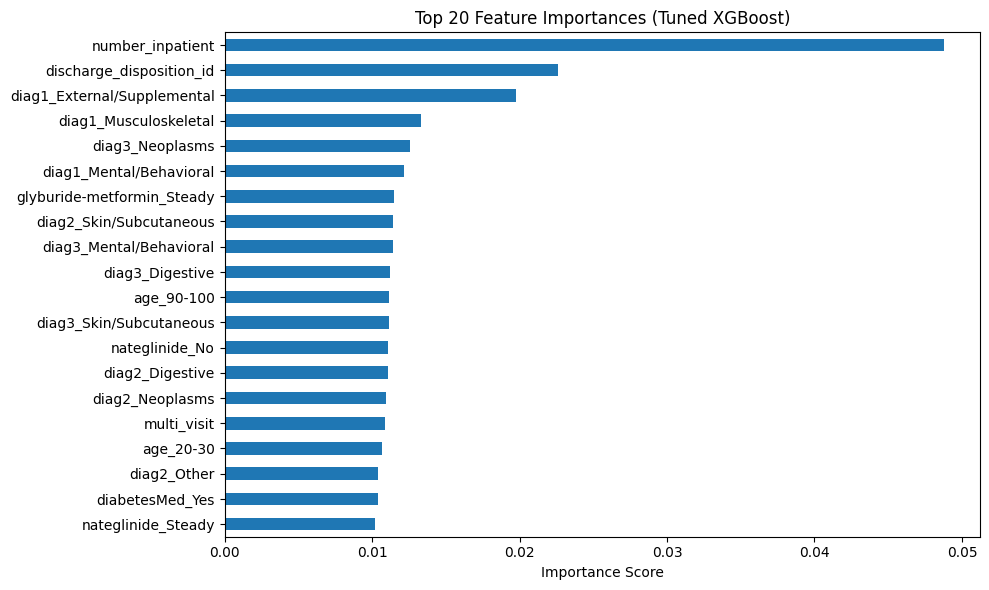

In [29]:
# top 20 features
print("\n=== 11) TOP 20 FEATURE IMPORTANCES FROM TUNED XGBOOST ===")
importances_xgb = pd.Series(data=xgb_best.feature_importances_, index=X_train.columns)
top_20_xgb = importances_xgb.sort_values(ascending=False).head(20)
print(top_20_xgb)


plt.figure(figsize=(10, 6))
top_20_xgb.sort_values().plot(kind='barh')
plt.title("Top 20 Feature Importances (Tuned XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [30]:
# final evaluation on the 20% hold-out test set (retrain each model on combined train + validation, then predict on test)

print("\n=== FINAL TEST SET EVALUATION ===\n")

# Combine train + validation into a single 80% “trainplusval” dataset
X_trainplusval = pd.concat([X_train, X_val], axis=0)
y_trainplusval = pd.concat([y_train, y_val], axis=0)


=== FINAL TEST SET EVALUATION ===



In [31]:
# catBoost final evaluation
cb_best.fit(X_trainplusval, y_trainplusval)
y_test_proba_cb = cb_best.predict_proba(X_test)[:, 1]
y_test_pred_cb = (y_test_proba_cb >= best_thresholds['CatBoost']).astype(int)
print("CatBoost Test Classification Report:")
print(classification_report(y_test, y_test_pred_cb, zero_division=0))
print(f"CatBoost Test ROC AUC: {roc_auc_score(y_test, y_test_proba_cb):.4f}\n")

CatBoost Test Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.63      0.75     18082
           1       0.18      0.63      0.28      2271

    accuracy                           0.63     20353
   macro avg       0.56      0.63      0.52     20353
weighted avg       0.85      0.63      0.70     20353

CatBoost Test ROC AUC: 0.6893



In [32]:
# Decision Tree final evaluation
dt_best.fit(X_trainplusval, y_trainplusval)
y_test_proba_dt = dt_best.predict_proba(X_test)[:, 1]
y_test_pred_dt = (y_test_proba_dt >= best_thresholds['DecisionTree']).astype(int)
print("Decision Tree Test Classification Report:")
print(classification_report(y_test, y_test_pred_dt, zero_division=0))
print(f"Decision Tree Test ROC AUC: {roc_auc_score(y_test, y_test_proba_dt):.4f}\n")

Decision Tree Test Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89     18082
           1       0.15      0.18      0.16      2271

    accuracy                           0.80     20353
   macro avg       0.52      0.53      0.52     20353
weighted avg       0.81      0.80      0.81     20353

Decision Tree Test ROC AUC: 0.5265



In [33]:
# Random Forest final evaluation
rf_best.fit(X_trainplusval, y_trainplusval)
y_test_proba_rf = rf_best.predict_proba(X_test)[:, 1]
y_test_pred_rf = (y_test_proba_rf >= best_thresholds['RandomForest']).astype(int)
print("Random Forest Test Classification Report:")
print(classification_report(y_test, y_test_pred_rf, zero_division=0))
print(f"Random Forest Test ROC AUC: {roc_auc_score(y_test, y_test_proba_rf):.4f}\n")

Random Forest Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.64      0.76     18082
           1       0.16      0.56      0.25      2271

    accuracy                           0.63     20353
   macro avg       0.54      0.60      0.51     20353
weighted avg       0.84      0.63      0.70     20353

Random Forest Test ROC AUC: 0.6423



In [34]:
# XGBoost final evaluation
xgb_best.fit(X_trainplusval, y_trainplusval)
y_test_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= best_thresholds['XGBoost']).astype(int)
print("XGBoost Test Classification Report:")
print(classification_report(y_test, y_test_pred_xgb, zero_division=0))
print(f"XGBoost Test ROC AUC: {roc_auc_score(y_test, y_test_proba_xgb):.4f}\n")

C:\Users\JunhuiHuTEST\PycharmProjects\Northeastern\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:51:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     18082
           1       0.18      0.63      0.28      2271

    accuracy                           0.64     20353
   macro avg       0.56      0.64      0.52     20353
weighted avg       0.85      0.64      0.71     20353

XGBoost Test ROC AUC: 0.6889



## week3

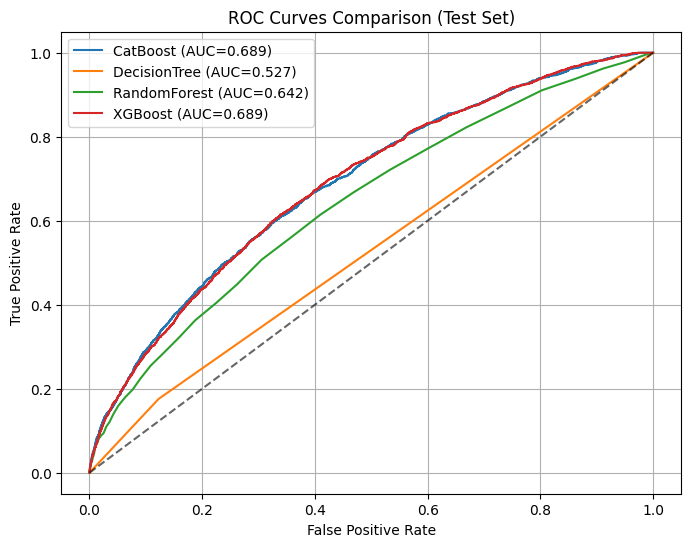

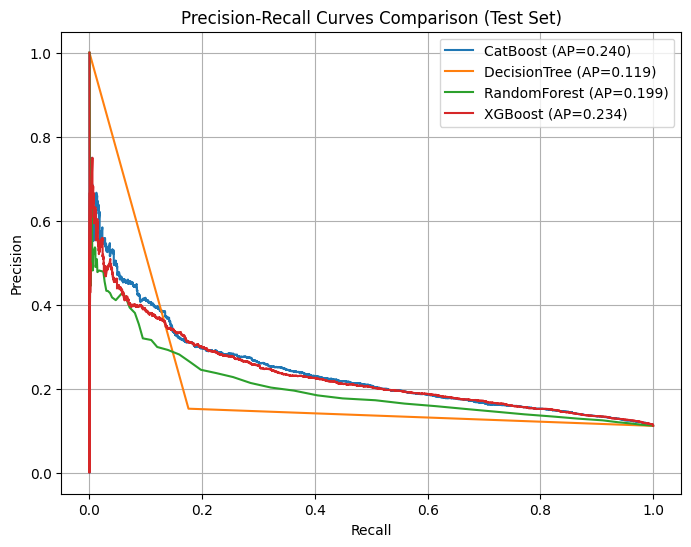

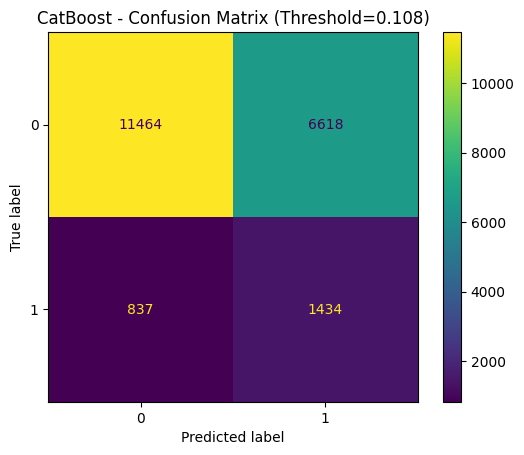

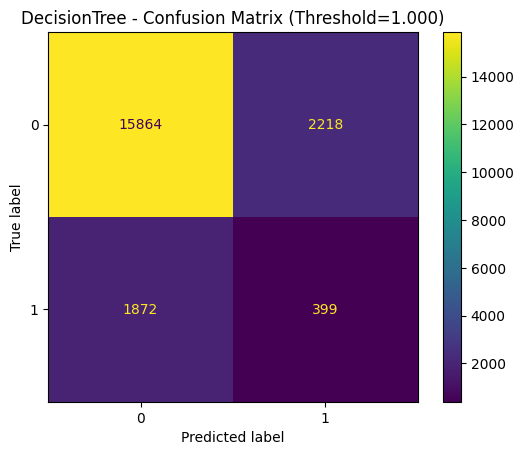

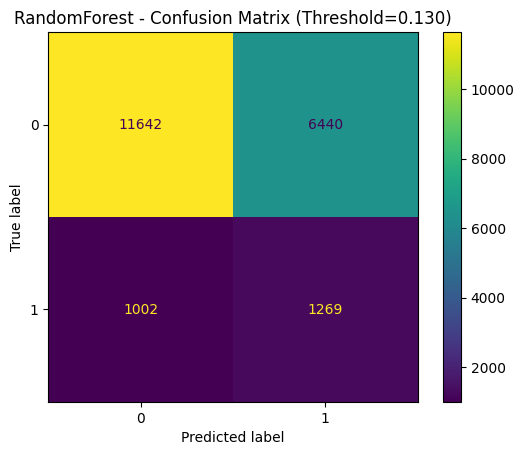

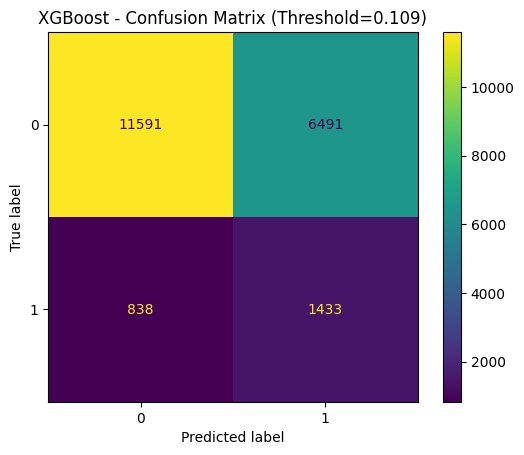

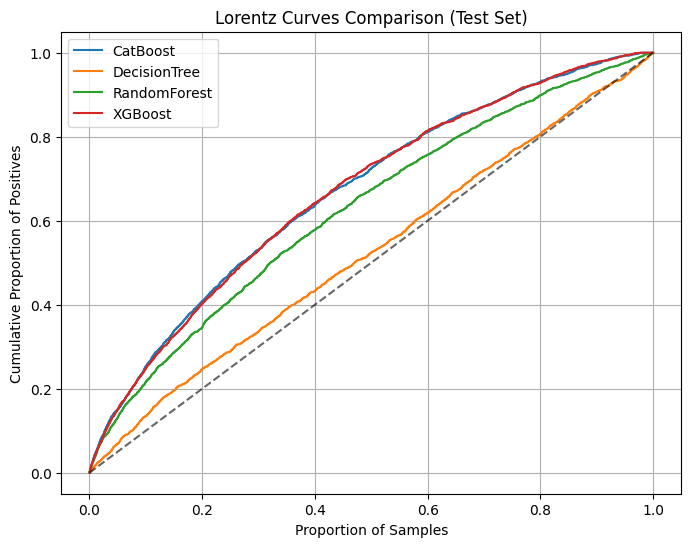

In [35]:


# storage prediction and label
model_results = {
    'CatBoost':    (y_test_proba_cb,   best_thresholds['CatBoost']),
    'DecisionTree':(y_test_proba_dt,   best_thresholds['DecisionTree']),
    'RandomForest':(y_test_proba_rf,   best_thresholds['RandomForest']),
    'XGBoost':     (y_test_proba_xgb,  best_thresholds['XGBoost']),
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # color form notebook

# ROC curve
plt.figure(figsize=(8,6))
for (name, (proba, _)), color in zip(model_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color)
plt.plot([0,1], [0,1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

# PR curve
plt.figure(figsize=(8,6))
for (name, (proba, _)), color in zip(model_results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})', color=color)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Comparison (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

# confusion matrix with best threshold
for (name, (proba, thr)) in model_results.items():
    y_pred = (proba >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix (Threshold={thr:.3f})")
    plt.show()

# Lorentz curve
plt.figure(figsize=(8,6))
for (name, (proba, _)), color in zip(model_results.items(), colors):
    sorted_idx = np.argsort(proba)[::-1]
    cum_true = np.cumsum(np.array(y_test)[sorted_idx])
    total_true = np.sum(y_test)
    lorentz = cum_true / total_true
    plt.plot(np.arange(1, len(lorentz)+1)/len(lorentz), lorentz, label=name, color=color)
plt.plot([0,1],[0,1],'k--', alpha=0.6)
plt.xlabel('Proportion of Samples')
plt.ylabel('Cumulative Proportion of Positives')
plt.title('Lorentz Curves Comparison (Test Set)')
plt.legend()
plt.grid(True)
plt.show()


In [36]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

results = []

for name, (proba, thr) in model_results.items():
    y_pred = (proba >= thr).astype(int)
    auc_score = roc_auc_score(y_test, proba)
    ap_score = average_precision_score(y_test, proba)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'AUC': auc_score,
        'AP': ap_score,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'Best Threshold': thr
    })

comparison_df = pd.DataFrame(results).set_index('Model')
print("\nModel Comparison:")
display(comparison_df)



Model Comparison:


,AUC,AP,Accuracy,Precision,Recall,F1 Score,Best Threshold
Model,,,,,,,
CatBoost,0.689284,0.240000,0.633715,0.178092,0.631440,0.277826,0.108090
DecisionTree,0.526515,0.118764,0.799047,0.152465,0.175694,0.163257,1.000000
RandomForest,0.642323,0.198979,0.634354,0.164613,0.558785,0.254309,0.130000
XGBoost,0.688900,0.233987,0.639906,0.180843,0.631000,0.281118,0.109135


In [38]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

In [43]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np
import shap


best_models = {
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
    'CatBoost': cb_best
}

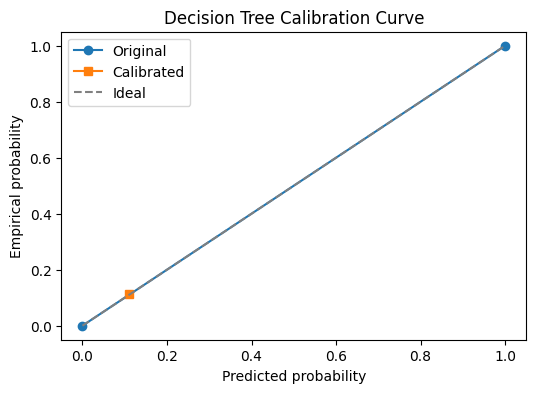

Decision Tree Brier score (original): 0.000
Decision Tree Brier score (calibrated): 0.094



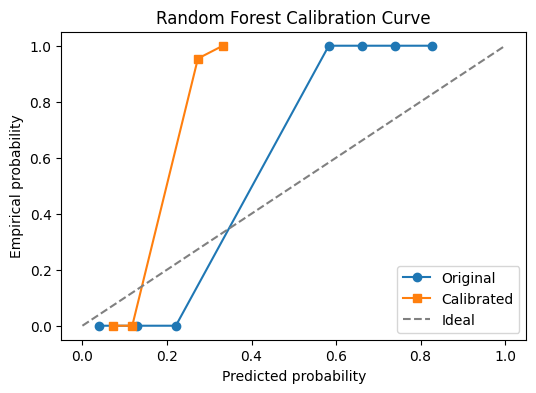

Random Forest Brier score (original): 0.013
Random Forest Brier score (calibrated): 0.061



C:\Users\JunhuiHuTEST\PycharmProjects\Northeastern\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:15:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\JunhuiHuTEST\PycharmProjects\Northeastern\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:15:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\JunhuiHuTEST\PycharmProjects\Northeastern\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:15:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


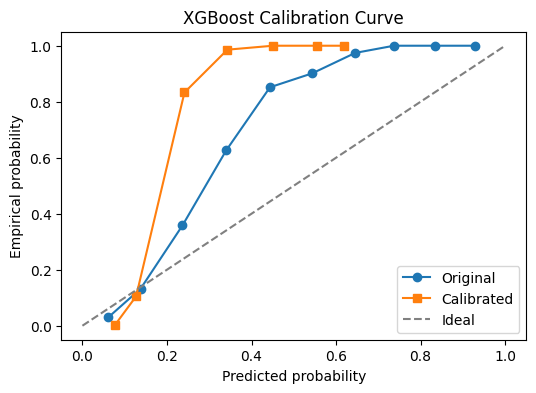

XGBoost Brier score (original): 0.080
XGBoost Brier score (calibrated): 0.078



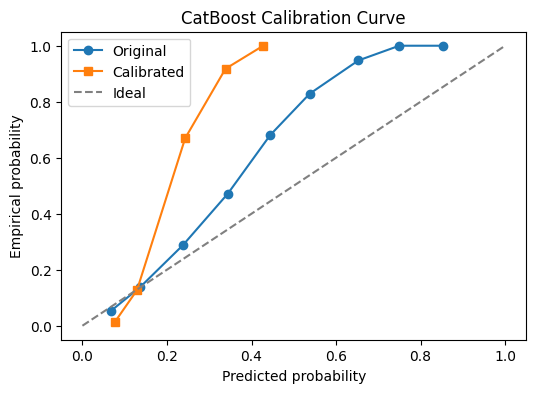

CatBoost Brier score (original): 0.089
CatBoost Brier score (calibrated): 0.083



In [44]:
# 1) Calibration curves and Brier scores on the validation set
for name, model in best_models.items():
    # Original predicted probabilities
    proba_orig = model.predict_proba(X_val)[:, 1]

    # Calibrate probabilities using isotonic regression
    calibrator = CalibratedClassifierCV(model, method='isotonic', cv=3)
    calibrator.fit(X_val, y_val)
    proba_cal = calibrator.predict_proba(X_val)[:, 1]

    # Compute reliability (calibration) curve
    frac_orig, mean_orig = calibration_curve(y_val, proba_orig, n_bins=10)
    frac_cal, mean_cal   = calibration_curve(y_val, proba_cal, n_bins=10)

    # Plot calibration curves
    plt.figure(figsize=(6, 4))
    plt.plot(mean_orig, frac_orig, 'o-', label='Original')
    plt.plot(mean_cal, frac_cal, 's-', label='Calibrated')
    plt.plot([0, 1], [0, 1], '--', color='gray', label='Ideal')
    plt.title(f'{name} Calibration Curve')
    plt.xlabel('Predicted probability')
    plt.ylabel('Empirical probability')
    plt.legend()
    plt.show()

    # Print Brier scores for comparison
    orig_brier = brier_score_loss(y_val, proba_orig)
    cal_brier  = brier_score_loss(y_val, proba_cal)
    print(f"{name} Brier score (original): {orig_brier:.3f}")
    print(f"{name} Brier score (calibrated): {cal_brier:.3f}\n")